# Superstore Sales Analysis
## Data Analysis Project (EDA + KPIs + Insights)

# Superstore Sales Analysis
## Data Analysis Project (EDA + KPIs + Insights)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


## 1. Data Loading

In [6]:
df = pd.read_csv(
    "../data/raw/Sample - Superstore.csv",
    encoding="latin1"
)

## 2. Data Exploration (EDA)

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [9]:
df.info

<bound method DataFrame.info of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520      

In [10]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 3. Data Cleaning

In [14]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

## 4. Feature Engineering (Date Handling)

In [16]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   str           
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [18]:
df["Month"] = df["Order Date"].dt.month_name()

In [21]:
df["Year"] = df["Order Date"].dt.year

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   str           
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [25]:
df.to_csv("../data/cleaned/sales_cleaned.csv", index=False)

## 5. KPIs (Business Metrics)

In [26]:
df["Sales"].sum()

np.float64(2297200.8603)

In [27]:
df["Profit"].sum()

np.float64(286397.0217)

In [29]:
df["Order ID"].nunique()

5009

In [30]:
df["Sales"].mean()

np.float64(229.85800083049827)

In [31]:
df["Profit"].sum()/df["Sales"].sum() #ganancia por venta

np.float64(0.12467217240315605)

In [32]:
df.groupby("Category")["Sales"].sum() #analisis por categoria

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

In [33]:
df.groupby("Category")["Profit"].sum() #ganania por categoria 

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

In [36]:
df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10) #Top clientes mejores ventas

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

In [37]:
df.groupby("Month")["Sales"].sum() #Time Series Analysis

Month
April        137762.1286
August       159044.0630
December     325293.5035
February      59751.2514
January       94924.8356
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     352461.0710
October      200322.9847
September    307649.9457
Name: Sales, dtype: float64

### Interpretación de los KPIs

Estos indicadores muestran el rendimiento general del negocio, incluyendo las ventas totales, la rentabilidad y el número de pedidos.

Nos permiten entender la escala del negocio y su eficiencia general.

## 6. Data Visualization

In [ ]:
sns.set_theme(style-"whitegrid")
plt.figure(figsize=10.5)

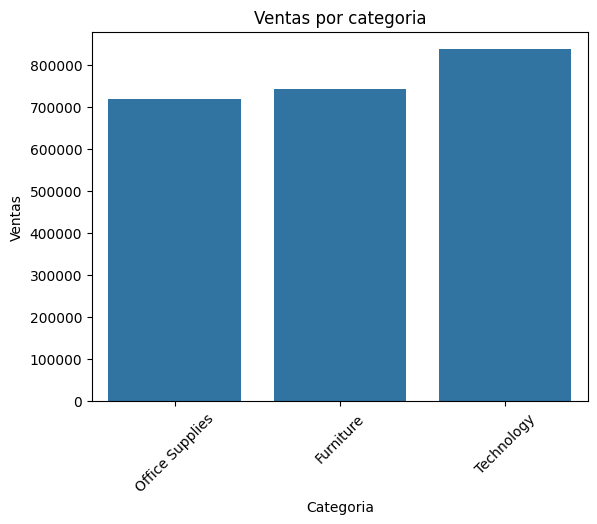

In [40]:
#ventas por categoria

category_sales = df.groupby("Category")["Sales"].sum().sort_values()

sns.barplot(x=category_sales.index , y=category_sales.values)

plt.title("Ventas por categoria")
plt.xlabel("Categoria")
plt.ylabel("Ventas")
plt.xticks(rotation=45)
plt.show()


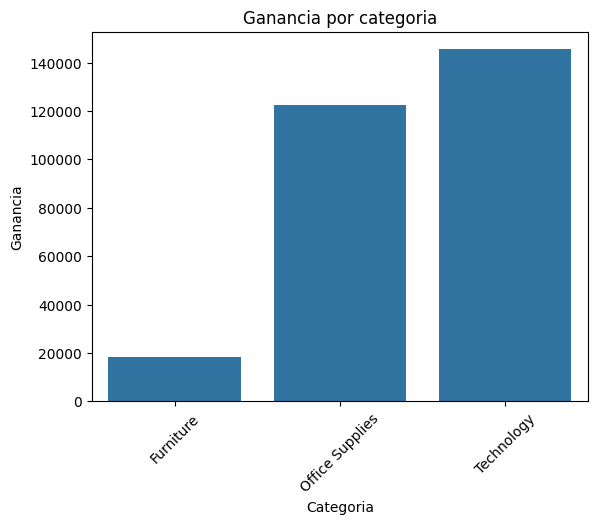

In [41]:
#ganancia por categoria

category_profit = df.groupby("Category")["Profit"].sum().sort_values()

sns.barplot(x=category_profit.index, y=category_profit.values)

plt.title("Ganancia por categoria")
plt.xlabel("Categoria")
plt.ylabel("Ganancia")
plt.xticks(rotation=45)
plt.show()

### Insight del análisis

Este gráfico nos ayuda a identificar qué categorías generan mayores ingresos y cómo se distribuyen las ventas entre los distintos segmentos.

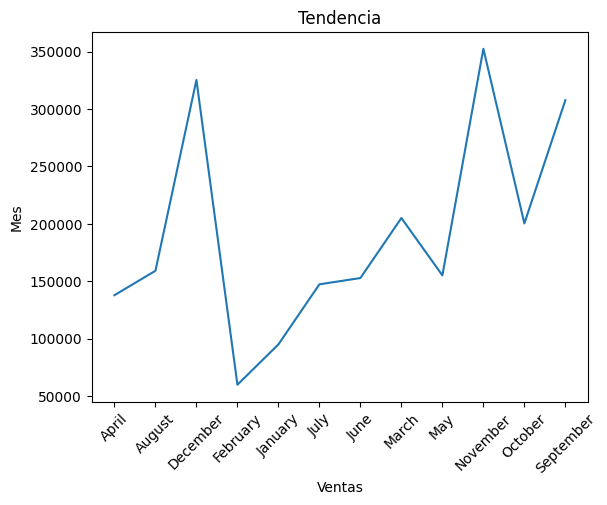

In [43]:
#Tendencia (ventas por mes)

monthly_sales = df.groupby("Month")["Sales"].sum()

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)

plt.title("Tendencia")
plt.xlabel("Ventas")
plt.ylabel("Mes")
plt.xticks(rotation=45)
plt.show()

### Tendencia temporal

El análisis de ventas a lo largo del tiempo permite identificar patrones de crecimiento y posibles efectos de estacionalidad en el negocio.Í

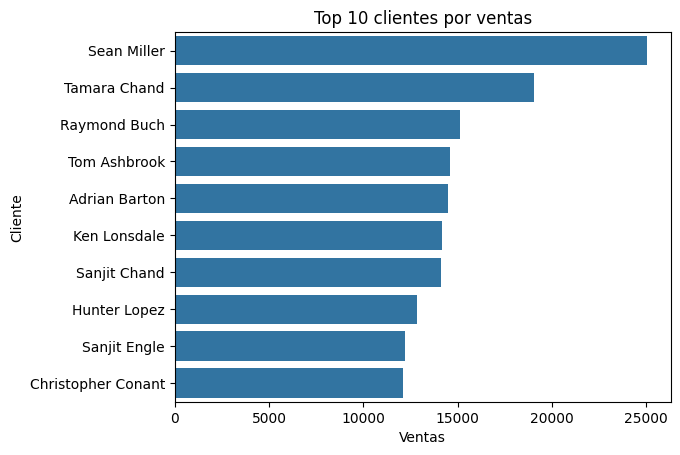

In [48]:
#Analisis de clientes

top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_customers.values, y=top_customers.index)

plt.title("Top 10 clientes por ventas")
plt.xlabel("Ventas")
plt.ylabel("Cliente")
plt.show()

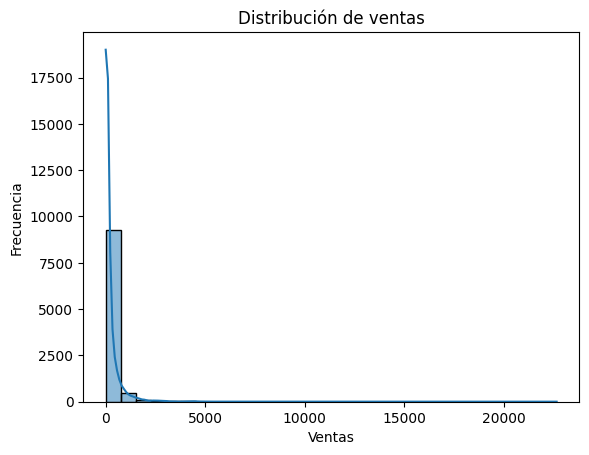

In [50]:
sns.histplot(df["Sales"], bins=30, kde=True)

plt.title("Distribución de ventas")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
plt.show()

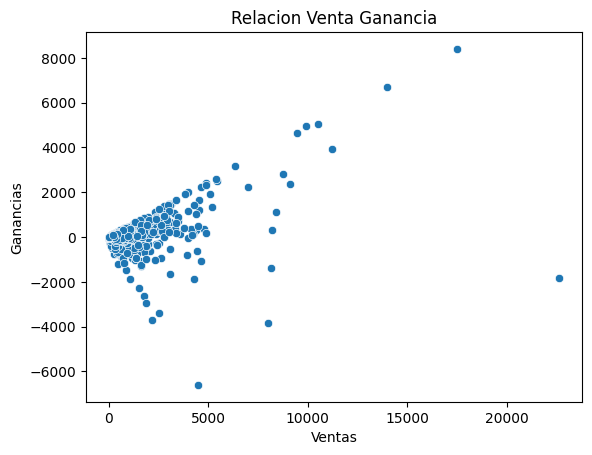

In [51]:
sns.scatterplot(data=df, x="Sales", y="Profit")

plt.title("Relacion Venta Ganancia")
plt.xlabel("Ventas")
plt.ylabel("Ganancias")
plt.show()

## 7. Business Insights

In [ ]:
## Conclusiones del análisis

A partir del análisis del dataset de ventas se obtuvieron los siguientes insights principales:

- Las ventas están concentradas en ciertas categorías, lo que indica que no todos los productos contribuyen de la misma 
manera al ingreso total.

- La ganancia no siempre sigue el mismo patrón que las ventas, lo que sugiere que algunos productos venden mucho pero 
tienen bajo margen de beneficio.

- Se observa una variación en las ventas a lo largo del tiempo, lo que puede indicar estacionalidad en el comportamiento 
de los clientes.

- Existe un grupo reducido de clientes que genera una parte importante de los ingresos totales, lo que indica dependencia 
de clientes clave.

- Algunas categorías presentan mejor rendimiento en términos de rentabilidad, lo cual puede ser útil para futuras decisiones 
de negocio.

En general, los datos permiten identificar oportunidades de mejora en la estrategia de ventas, especialmente en la optimización de productos
y enfoque en clientes más rentables.

## Recomendaciones

- Enfocar esfuerzos en las categorías más rentables.
- Revisar productos con alta venta pero bajo margen de ganancia.
- Implementar estrategias de fidelización para clientes principales.
- Analizar la estacionalidad para optimizar campañas de marketing.

## Impacto del análisis

Este análisis permite a la empresa tomar decisiones basadas en datos para mejorar la rentabilidad, optimizar 
inventario y enfocar estrategias comerciales en los segmentos más valiosos.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [6]:
df = pd.read_csv(
    "../data/raw/Sample - Superstore.csv",
    encoding="latin1"
)

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [9]:
df.info

<bound method DataFrame.info of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520      

In [10]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [14]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   str           
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [18]:
df["Month"] = df["Order Date"].dt.month_name()

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   str           
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [21]:
df["Year"] = df["Order Date"].dt.year

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   str           
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [23]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month,Year
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,November,2016
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,November,2016
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,June,2016
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,October,2015
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,October,2015


In [25]:
df.to_csv("../data/cleaned/sales_cleaned.csv", index=False)

In [26]:
df["Sales"].sum()

np.float64(2297200.8603)

In [27]:
df["Profit"].sum()

np.float64(286397.0217)

In [29]:
df["Order ID"].nunique()

5009

In [30]:
df["Sales"].mean()

np.float64(229.85800083049827)

In [31]:
df["Profit"].sum()/df["Sales"].sum() #ganancia por venta

np.float64(0.12467217240315605)

In [32]:
df.groupby("Category")["Sales"].sum() #analisis por categoria

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

In [33]:
df.groupby("Category")["Profit"].sum() #ganania por categoria 

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

In [36]:
df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10) #Top clientes mejores ventas

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

In [37]:
df.groupby("Month")["Sales"].sum() #Time Series Analysis

Month
April        137762.1286
August       159044.0630
December     325293.5035
February      59751.2514
January       94924.8356
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     352461.0710
October      200322.9847
September    307649.9457
Name: Sales, dtype: float64

In [ ]:
sns.set_theme(style-"whitegrid")
plt.figure(figsize=10.5)

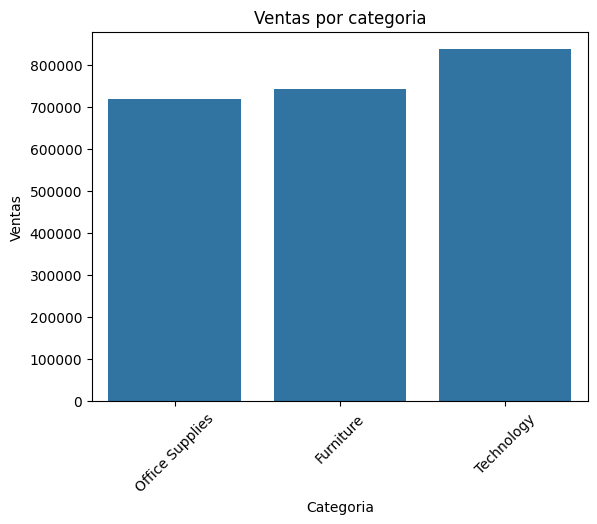

In [40]:
#ventas por categoria

category_sales = df.groupby("Category")["Sales"].sum().sort_values()

sns.barplot(x=category_sales.index , y=category_sales.values)

plt.title("Ventas por categoria")
plt.xlabel("Categoria")
plt.ylabel("Ventas")
plt.xticks(rotation=45)
plt.show()


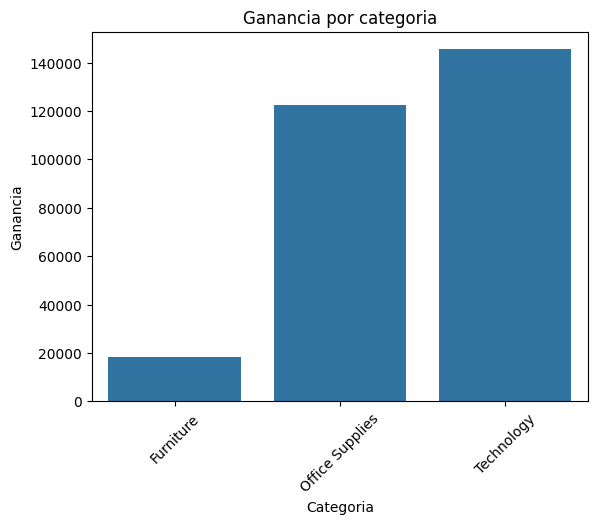

In [41]:
#ganancia por categoria

category_profit = df.groupby("Category")["Profit"].sum().sort_values()

sns.barplot(x=category_profit.index, y=category_profit.values)

plt.title("Ganancia por categoria")
plt.xlabel("Categoria")
plt.ylabel("Ganancia")
plt.xticks(rotation=45)
plt.show()

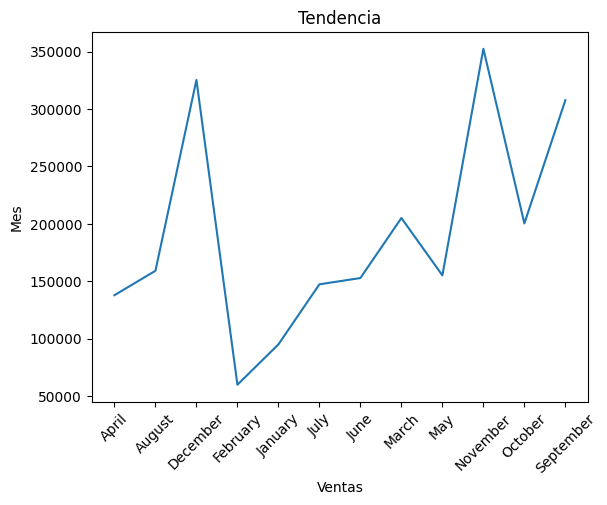

In [43]:
#Tendencia (ventas por mes)

monthly_sales = df.groupby("Month")["Sales"].sum()

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)

plt.title("Tendencia")
plt.xlabel("Ventas")
plt.ylabel("Mes")
plt.xticks(rotation=45)
plt.show()

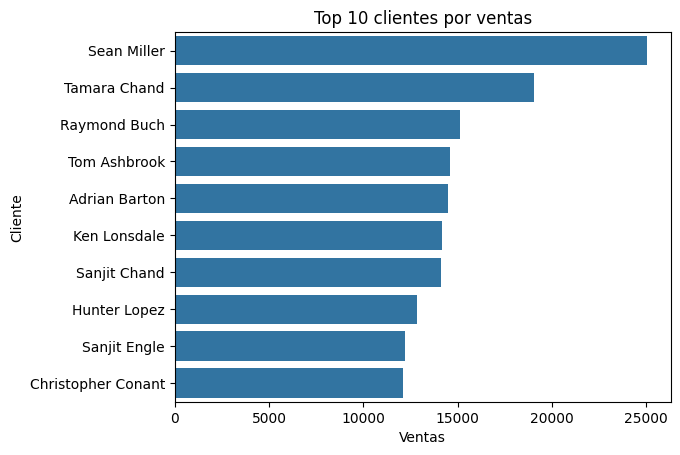

In [48]:
#Analisis de clientes

top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_customers.values, y=top_customers.index)

plt.title("Top 10 clientes por ventas")
plt.xlabel("Ventas")
plt.ylabel("Cliente")
plt.show()

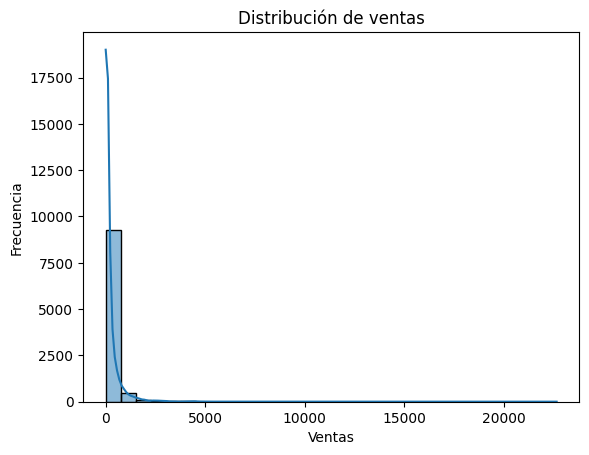

In [50]:
sns.histplot(df["Sales"], bins=30, kde=True)

plt.title("Distribución de ventas")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
plt.show()

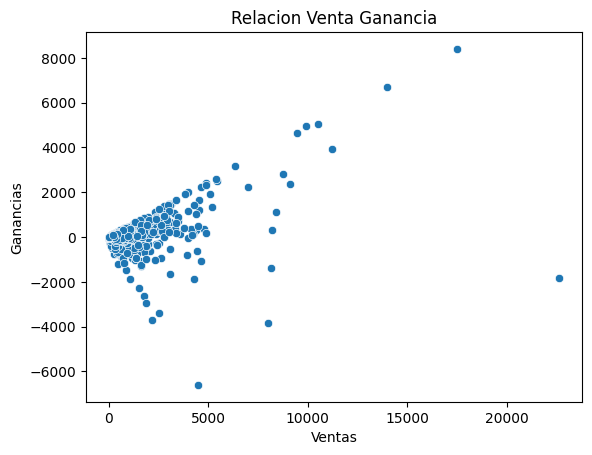

In [51]:
sns.scatterplot(data=df, x="Sales", y="Profit")

plt.title("Relacion Venta Ganancia")
plt.xlabel("Ventas")
plt.ylabel("Ganancias")
plt.show